# General Additive Models

In [6]:
df.to_csv("Enhanced.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_parquet("../data/Parquet/Enhanced.parquet")

print(df.columns)
print(df.shape)

Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Distance',
       'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE',
       'baseline_depth', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED',
       'K_PAR'],
      dtype='object')
(2388, 40)
Index(['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC',
       'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE',
       'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR',
       'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Distance',
       'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi',
       'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE',
   

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



Visualize the relationships between the PAR variables and 'Secchi'

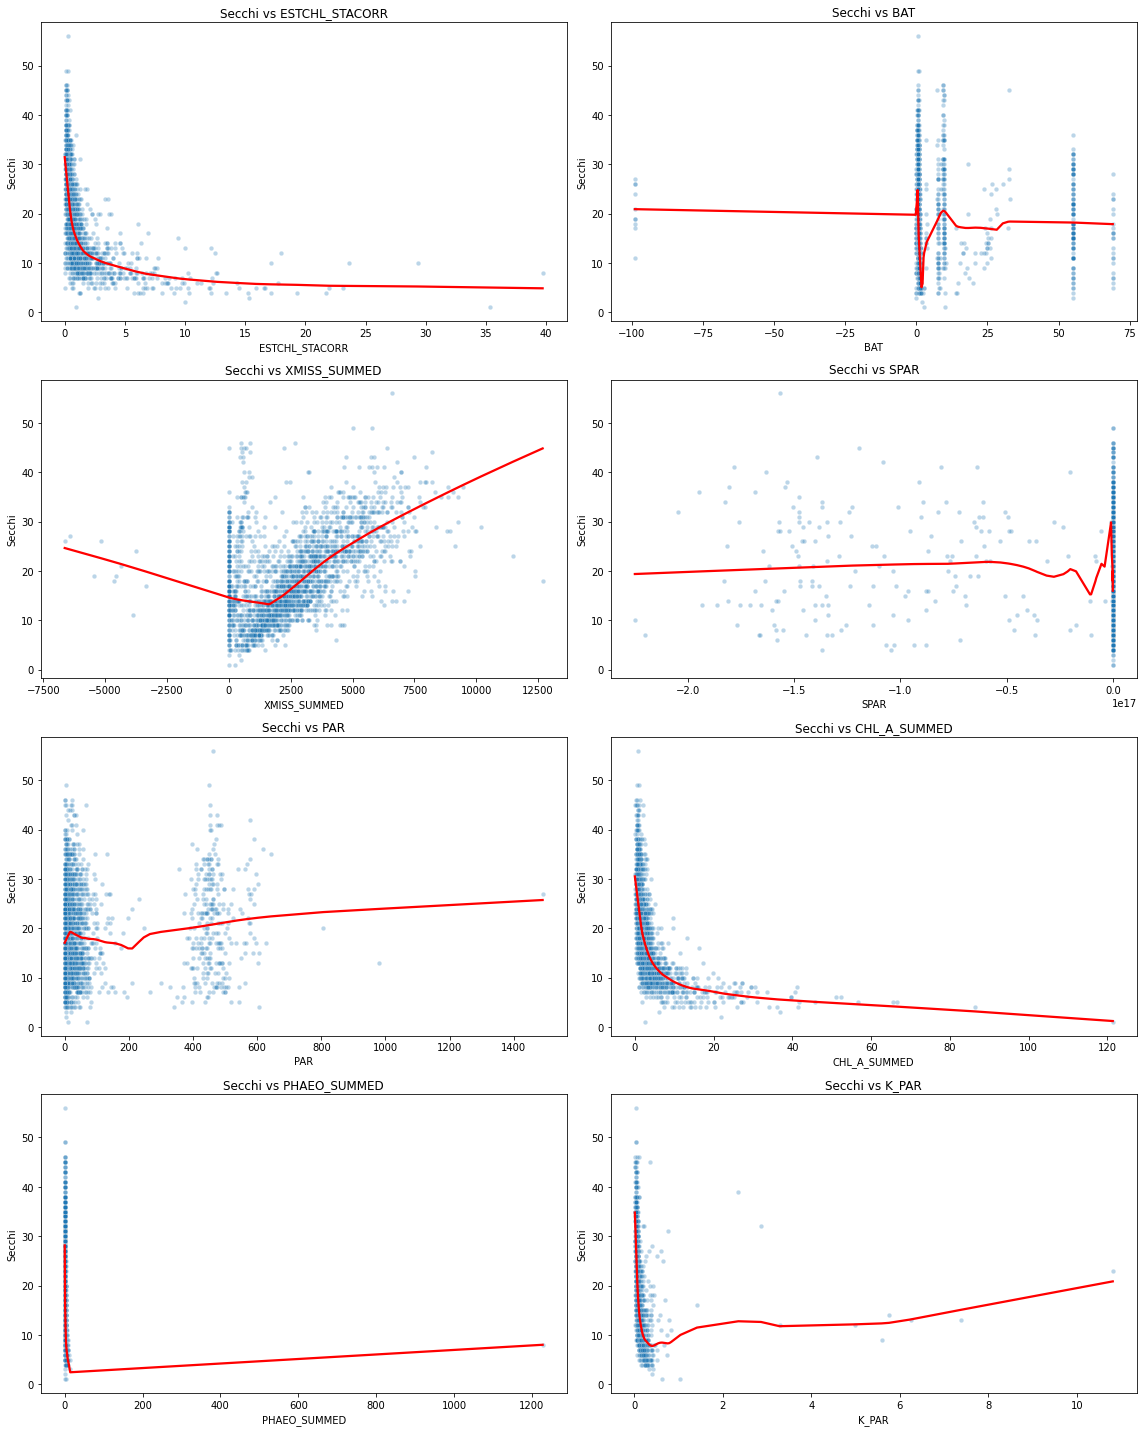

In [42]:
variables = [
    'ESTCHL_STACORR',
    'BAT',
    'XMISS_SUMMED',
    'SPAR',
    'PAR',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'K_PAR'
]

n_cols = 2
n_rows = int(np.ceil(len(variables) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    temp = df[[var, 'Secchi']].dropna()
    
    sns.scatterplot(
        data=temp,
        x=var,
        y='Secchi',
        alpha=0.3,
        s=20,
        ax=axes[i]
    )
    
    axes[i].set_title(f'Secchi vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Secchi')

    sns.regplot(
    data=temp,
    x=var,
    y='Secchi',
    lowess=True,
    scatter=False,
    color='red',
    ax=axes[i]
)


plt.tight_layout()
plt.savefig("secchi_vs_all_variables.png", dpi=300, bbox_inches='tight')
plt.show()

Result: 

CHL_A_SUMMED has nonlinear decay.
ESTCHL_STACORR has nonlinear decay. High chlorophyll -> low Secchi.
XMISS_SUMMED has nonlinear increasing relationship. More transmissometer signal -> clearer water -> higher Secchi.
K_PAR shows low attenuation -> high Secchi.

In [43]:
# Create a new dataset with only the relevant variables and drop rows with missing values

cols = ['Secchi'] + variables
df = df[cols].dropna()

In [44]:
# Create the design matrix X and response vector y

X = df[variables].values
y = df['Secchi'].values

Model 1: Secchi ~ smooth(K_PAR)

In [46]:
# Start with strongest predictor: K_PAR
from pygam import LinearGAM, s

X_kpar = X[:, [7]]  # extract K_PAR column

gam1 = LinearGAM(s(0)).fit(X_kpar, y)
print(gam1.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.9796
Link Function:                     IdentityLink Log Likelihood:                                -10061.8351
Number of Samples:                         2148 AIC:                                            20139.6293
                                                AICc:                                           20139.6963
                                                GCV:                                               42.9282
                                                Scale:                                             42.6772
                                                Pseudo R-Squared:                                   0.4193
Feature Function                  Lam

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/986216008.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam1.summary())


AIC: 20139.6293
Pseudo R-Squared: 0.4193
Effective Degrees of Freedom: 6.9796 
    If EDF ≈ 1 -> essentially linear
    If EDF ≈ 15+ -> potentially overfitting

In [48]:
from pygam import LinearGAM, s

# Model 1: K_PAR only

X_kpar = df[['K_PAR']].values

gam1 = LinearGAM(
    s(0)
).fit(X_kpar, y)

print("Model 1: K_PAR")
print(gam1.summary())


# Model 2: K_PAR + CHL_A_SUMMED


X_kpar_chl = df[['K_PAR', 'CHL_A_SUMMED']].values

gam2 = LinearGAM(
    s(0) + s(1)
).fit(X_kpar_chl, y)

print("\nModel 2: K_PAR + CHL_A_SUMMED")
print(gam2.summary())


# Model 3: K_PAR + CHL_A_SUMMED + XMISS_SUMMED


X_kpar_chl_xmiss = df[['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED']].values

gam3 = LinearGAM(
    s(0) + s(1) + s(2)
).fit(X_kpar_chl_xmiss, y)

print("\nModel 3: + XMISS_SUMMED")
print(gam3.summary())



# Model 4: Add ESTCHL_STACORR


X_kpar_chl_xmiss_est = df[['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED', 'ESTCHL_STACORR']].values

gam4 = LinearGAM(
    s(0) + s(1) + s(2) + s(3)
).fit(X_kpar_chl_xmiss_est, y)

print("\nModel 4: + ESTCHL_STACORR")
print(gam4.summary())



# Model 5: Full Model (All Predictors)


X_full = df[[
    'ESTCHL_STACORR',
    'BAT',
    'XMISS_SUMMED',
    'SPAR',
    'PAR',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'K_PAR'
]].values

gam_full = LinearGAM(
    s(0) + s(1) + s(2) + s(3) +
    s(4) + s(5) + s(6) + s(7)
).fit(X_full, y)

print("\nModel 5: Full Model")
print(gam_full.summary())

Model 1: K_PAR
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.9796
Link Function:                     IdentityLink Log Likelihood:                                -10061.8351
Number of Samples:                         2148 AIC:                                            20139.6293
                                                AICc:                                           20139.6963
                                                GCV:                                               42.9282
                                                Scale:                                             42.6772
                                                Pseudo R-Squared:                                   0.4193
Feature Function      

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/3261213636.py:12: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam1.summary())
/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/3261213636.py:25: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam2.summary())



Model 3: + XMISS_SUMMED
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     25.3495
Link Function:                     IdentityLink Log Likelihood:                                 -8798.7632
Number of Samples:                         2148 AIC:                                            17650.2252
                                                AICc:                                           17650.9049
                                                GCV:                                               23.9922
                                                Scale:                                             23.4831
                                                Pseudo R-Squared:                                   0.6832
Feature Func

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/3261213636.py:38: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam3.summary())



Model 4: + ESTCHL_STACORR
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     33.4768
Link Function:                     IdentityLink Log Likelihood:                                 -8762.0924
Number of Samples:                         2148 AIC:                                            17593.1383
                                                AICc:                                           17594.2963
                                                GCV:                                               23.7441
                                                Scale:                                             23.0789
                                                Pseudo R-Squared:                                   0.6898
Feature Fu

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/3261213636.py:52: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam4.summary())



Model 5: Full Model
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     56.0596
Link Function:                     IdentityLink Log Likelihood:                                 -8674.2415
Number of Samples:                         2148 AIC:                                            17462.6021
                                                AICc:                                           17465.7724
                                                GCV:                                               23.2279
                                                Scale:                                             22.1393
                                                Pseudo R-Squared:                                   0.7056
Feature Function

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_54634/3261213636.py:76: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_full.summary())


In [ ]:
print("AIC Comparison")
print("Model 1:", gam1.statistics_["AIC"])
print("Model 2:", gam2.statistics_["AIC"])
print("Model 3:", gam3.statistics_["AIC"])
print("Model 4:", gam4.statistics_["AIC"])
print("Full Model:", gam_full.statistics_["AIC"])

AIC Comparison
Model 1: 20139.62927038192
Model 2: 18141.009449245477
Model 3: 17650.22523776593
Model 4: 17593.138294072392
Full Model: 17462.60209848219
Pseudo R2
Model 1: OrderedDict([('explained_deviance', 0.4192544164272479), ('McFadden', 0.9982034939314983), ('McFadden_adj', 0.0011040853803910844)])
Model 2: OrderedDict([('explained_deviance', 0.6404802711302351), ('McFadden', 0.9921480445339427), ('McFadden_adj', 0.006234200637373455)])
Model 3: OrderedDict([('explained_deviance', 0.6831873484529607), ('McFadden', 0.9890446710768331), ('McFadden_adj', 0.008105866624228297)])
Model 4: OrderedDict([('explained_deviance', 0.6898314409616524), ('McFadden', 0.9885056858134079), ('McFadden_adj', 0.007717594019549301)])
Full Model: OrderedDict([('explained_deviance', 0.7056375206698235), ('McFadden', 0.9871118785852812), ('McFadden_adj', 0.006508652377549162)])


In [51]:
print("Pseudo R2")
print("Model 1:", gam1.statistics_["pseudo_r2"])
print("Model 2:", gam2.statistics_["pseudo_r2"])
print("Model 3:", gam3.statistics_["pseudo_r2"])
print("Model 4:", gam4.statistics_["pseudo_r2"])
print("Full Model:", gam_full.statistics_["pseudo_r2"])

Pseudo R2
Model 1: OrderedDict([('explained_deviance', 0.4192544164272479), ('McFadden', 0.9982034939314983), ('McFadden_adj', 0.0011040853803910844)])
Model 2: OrderedDict([('explained_deviance', 0.6404802711302351), ('McFadden', 0.9921480445339427), ('McFadden_adj', 0.006234200637373455)])
Model 3: OrderedDict([('explained_deviance', 0.6831873484529607), ('McFadden', 0.9890446710768331), ('McFadden_adj', 0.008105866624228297)])
Model 4: OrderedDict([('explained_deviance', 0.6898314409616524), ('McFadden', 0.9885056858134079), ('McFadden_adj', 0.007717594019549301)])
Full Model: OrderedDict([('explained_deviance', 0.7056375206698235), ('McFadden', 0.9871118785852812), ('McFadden_adj', 0.006508652377549162)])


Cross validate all models

In [ ]:
# Function to perform 5-fold cross-validation and compute RMSE and R² for each model
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from pygam import LinearGAM, s

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cross_validate_gam(Xdata, ydata, gam_structure):
    """
    Xdata: predictor matrix
    ydata: response
    gam_structure: e.g., s(0) + s(1) + s(2)
    """
    rmse_scores = []
    r2_scores = []
    
    for train_idx, test_idx in kf.split(Xdata):
        X_train, X_test = Xdata[train_idx], Xdata[test_idx]
        y_train, y_test = ydata[train_idx], ydata[test_idx]
        
        gam = LinearGAM(gam_structure)
        gam.fit(X_train, y_train)
        
        preds = gam.predict(X_test)
        
        # RMSE
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmse_scores.append(rmse)
        
        # R²
        ss_res = np.sum((y_test - preds)**2)
        ss_tot = np.sum((y_test - np.mean(y_train))**2)
        r2 = 1 - ss_res/ss_tot
        r2_scores.append(r2)
    
    return (
        np.mean(rmse_scores),
        np.std(rmse_scores),
        np.mean(r2_scores),
        np.std(r2_scores)
    )

In [55]:
# Prepare predictor matrices for each model
# Model 1
X1 = df[['K_PAR']].values

# Model 2
X2 = df[['K_PAR', 'CHL_A_SUMMED']].values

# Model 3
X3 = df[['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED']].values

# Model 4
X4 = df[['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED', 'ESTCHL_STACORR']].values

# Full Model
X_full = df[[
    'ESTCHL_STACORR',
    'BAT',
    'XMISS_SUMMED',
    'SPAR',
    'PAR',
    'CHL_A_SUMMED',
    'PHAEO_SUMMED',
    'K_PAR'
]].values

y = df['Secchi'].values

In [56]:
# Cross validate all models and store results
results = {}

results["Model 1"] = cross_validate_gam(X1, y, s(0))
results["Model 2"] = cross_validate_gam(X2, y, s(0)+s(1))
results["Model 3"] = cross_validate_gam(X3, y, s(0)+s(1)+s(2))
results["Model 4"] = cross_validate_gam(X4, y, s(0)+s(1)+s(2)+s(3))
results["Full Model"] = cross_validate_gam(
    X_full, y,
    s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6)+s(7)
)

for name, vals in results.items():
    print(f"{name}:")
    print(f"  RMSE: {vals[0]:.3f} ± {vals[1]:.3f}")
    print(f"  R²:   {vals[2]:.3f} ± {vals[3]:.3f}")
    print()

Model 1:
  RMSE: 6.304 ± 0.140
  R²:   0.457 ± 0.027

Model 2:
  RMSE: 5.064 ± 0.172
  R²:   0.650 ± 0.015

Model 3:
  RMSE: 4.843 ± 0.149
  R²:   0.679 ± 0.019

Model 4:
  RMSE: 4.801 ± 0.146
  R²:   0.685 ± 0.020

Full Model:
  RMSE: 7.224 ± 4.755
  R²:   -0.046 ± 1.456



From model 1 -> model 2: Adding CHL_A_SUMMED improved R^2 a lot.
From model 2 -> model 3: Adding XMISS_SUMMED improved R^2 somewhat.


Highest R^2 was in model 4, however it is only 0.006 more than model 3. Although model 4 has a lower RMSE, it is only lower by 0.032. Given the complexity of an extra predictor in model 4 and slight better performance, model 3 is best based on bias–variance tradeoff.

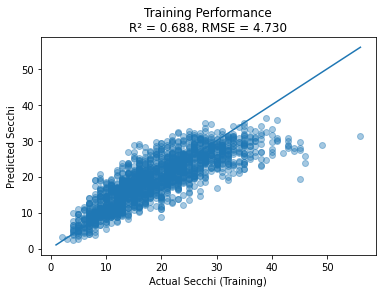

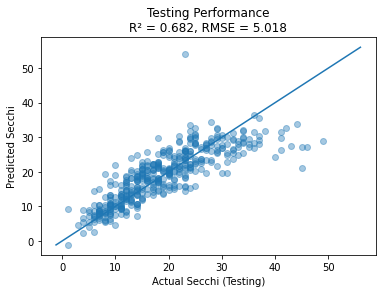

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from pygam import LinearGAM, s

# Prepare Model 3 predictors
X3 = df[['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED']].values
y = df['Secchi'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(kf.split(X3))

X_train, X_test = X3[train_idx], X3[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Fit model
gam_temp = LinearGAM(s(0) + s(1) + s(2)).fit(X_train, y_train)

pred_train = gam_temp.predict(X_train)
pred_test = gam_temp.predict(X_test)

# ---- TRAINING METRICS ----
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
ss_res_train = np.sum((y_train - pred_train)**2)
ss_tot_train = np.sum((y_train - np.mean(y_train))**2)
r2_train = 1 - ss_res_train / ss_tot_train

# ---- TESTING METRICS ----
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
ss_res_test = np.sum((y_test - pred_test)**2)
ss_tot_test = np.sum((y_test - np.mean(y_train))**2)
r2_test = 1 - ss_res_test / ss_tot_test

# -------------------
# Training Plot
# -------------------
plt.figure()
plt.scatter(y_train, pred_train, alpha=0.4)

min_val = min(y.min(), pred_train.min())
max_val = max(y.max(), pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Secchi (Training)")
plt.ylabel("Predicted Secchi")
plt.title(f"Training Performance\nR² = {r2_train:.3f}, RMSE = {rmse_train:.3f}")
plt.show()

# -------------------
# Testing Plot
# -------------------
plt.figure()
plt.scatter(y_test, pred_test, alpha=0.4)

min_val = min(y.min(), pred_test.min())
max_val = max(y.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Secchi (Testing)")
plt.ylabel("Predicted Secchi")
plt.title(f"Testing Performance\nR² = {r2_test:.3f}, RMSE = {rmse_test:.3f}")
plt.show()

## Trying to improve model performance: